In [1]:
import glob
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

from cellbender.remove_background.downstream import anndata_from_h5

from tqdm import tqdm

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

In [2]:
SAWADA_CELLBENDER_OUTPUTS = glob.glob('/mnt/lacie/scz_meta_analysis/cellbender/sawada_kato/*/*output.h5')

In [3]:
# Load all AnnData objects
ad_list = [anndata_from_h5(fp) for fp in SAWADA_CELLBENDER_OUTPUTS]
srr_list = [fp.split('/')[-1].split('_')[0] for fp in SAWADA_CELLBENDER_OUTPUTS]

# Prep Individual Libraries
for adata, srr in tqdm(zip(ad_list, srr_list)):
    # Prepend SRR ID to cell barcodes
    adata.obs_names = [f"{srr}_{obs}" for obs in adata.obs_names]
    # Set gene_names to unique ENSEMBLE names
    adata.var['gene_name'] = adata.var_names
    adata.var_names = adata.var['gene_id']

# Concatenate
sawada_adata = sc.concat(ad_list, join='outer', label='library', keys=srr_list)

/home/deepak/pixi_envs/cellbender/.pixi/envs/default/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/deepak/pixi_envs/cellbender/.pixi/envs/default/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/deepak/pixi_envs/cellbender/.pixi/envs/default/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/deepak/pixi_envs/cellbender/.pixi/envs/default/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/deepak/pixi_envs/cellbender/.pixi/envs/default/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is depreca

In [4]:
sawada_adata.obs['nUMIs'] = sawada_adata.X.sum(axis=1)

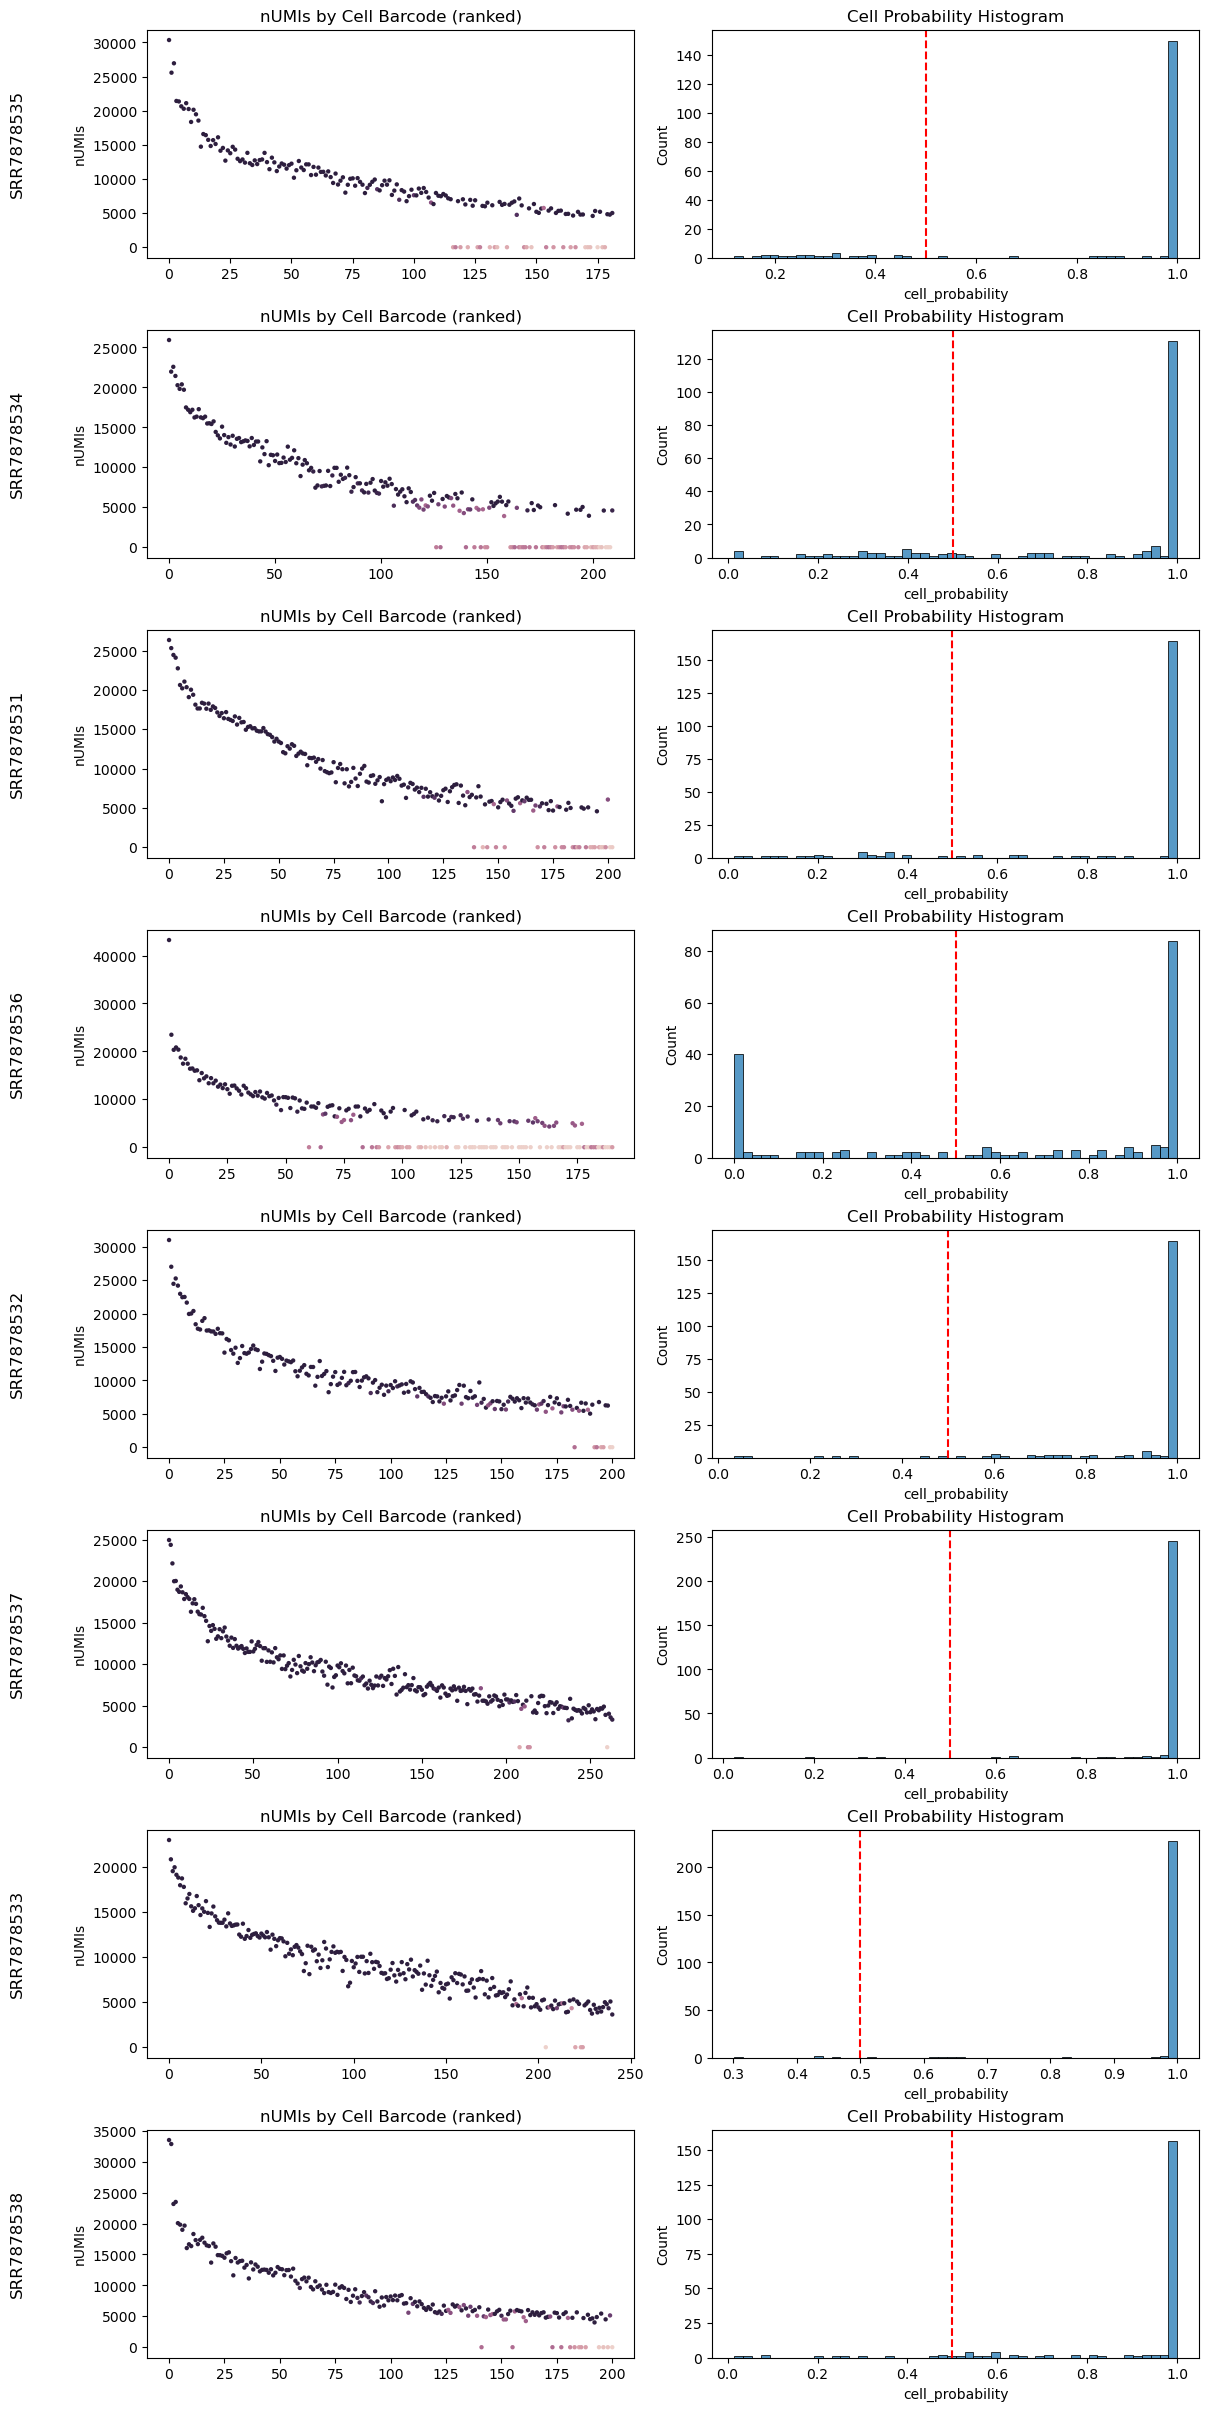

In [5]:
## Visualize Ambient RNA Filtration ##

n = len(srr_list)

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(12, 3 * n),   # <-- scale height per SRR
    constrained_layout=True
)

for i, srr in enumerate(srr_list):
    cb_table = sawada_adata.obs[sawada_adata.obs['library'] == srr]

    # Scatter plot
    sns.scatterplot(
        data=cb_table,
        x=range(cb_table.shape[0]),
        y='nUMIs',
        hue='cell_probability',
        ax=axes[i, 0],
        s=10,
        linewidth=0
    )
    axes[i, 0].set_title('nUMIs by Cell Barcode (ranked)')
    axes[i, 0].set_xlabel('')
    axes[i, 0].legend_.remove()

    # Histogram
    sns.histplot(
        data=cb_table,
        x='cell_probability',
        ax=axes[i, 1],
        bins=50
    )
    axes[i, 1].axvline(0.5, color='red', linestyle='--')
    axes[i, 1].set_title('Cell Probability Histogram')

    # Left-side SRR label (per row)
    axes[i, 0].annotate(
        srr,
        xy=(-0.25, 0.5),
        xycoords='axes fraction',
        va='center',
        ha='right',
        fontsize=12,
        rotation=90
    )

plt.show()

In [6]:
## Percentage of Cells ##

sawada_adata.obs['cell'] = (sawada_adata.obs['cell_probability'] > 0.5)

print('Total Cells: {0}'.format(sawada_adata.shape[0]))

print('Cells After Ambient RNA Filtration: {0}'.format(sawada_adata.obs['cell'].sum()))

print('Cells Percentage: {0}%'.format(np.round(100*sawada_adata.obs['cell'].sum() / sawada_adata.shape[0]),2))

Total Cells: 1693
Cells After Ambient RNA Filtration: 1508
Cells Percentage: 89.0%


In [7]:
## Save Step ##

sawada_adata.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/sawada_kato/anndata_objs/sawada_cellbendered.h5ad')